In [1]:
print("Hello World!!!")

Hello World!!!


# Hospital Insurance Claim

### Loading the  Required Libraries

In [2]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import seaborn as sns

In [12]:
sns.set_style("darkgrid")

In [6]:
import matplotlib.pyplot as plt

### Loading the data

In [7]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\Data Science Projects\Health Insurance Prediction\insurance.csv")

In [8]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


### Data Inspecction and Cleaning

In [9]:
df.sample(5)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
813,814,35.0,male,18.3,95,No,0,No,northeast,11534.87
1051,1052,33.0,male,36.2,100,No,0,No,southeast,19214.71
490,491,54.0,female,32.2,89,No,1,No,southwest,6775.96
1257,1258,43.0,male,36.7,139,Yes,1,Yes,northeast,39774.28
1041,1042,30.0,female,27.9,84,No,3,No,northwest,18838.70


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [11]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [16]:
df.isna().sum().sum()

8

There are about 8 missing values

In [17]:
pd.set_option("display.float_format", "{:.2f}".format)

In [18]:
sns.set(style= "darkgrid", palette= "Set2", font_scale= 1.1)

In [19]:
df.duplicated().sum()

0

In [20]:
df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [21]:
df.isna().sum().sum()

8

dropping the 8 missing values, cos they wont really have much impact.

In [22]:
df.dropna(inplace=True)

In [23]:
df.isna().sum().sum()

0

In [24]:
df.dtypes

Id                 int64
age              float64
gender            object
bmi              float64
bloodpressure      int64
diabetic          object
children           int64
smoker            object
region            object
claim            float64
dtype: object

In [25]:
df.describe(exclude="object")

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


In [26]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


In [27]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim'],
      dtype='object')

In [14]:
num_cols = ["age","bmi","bloodpressure","children","claim"]

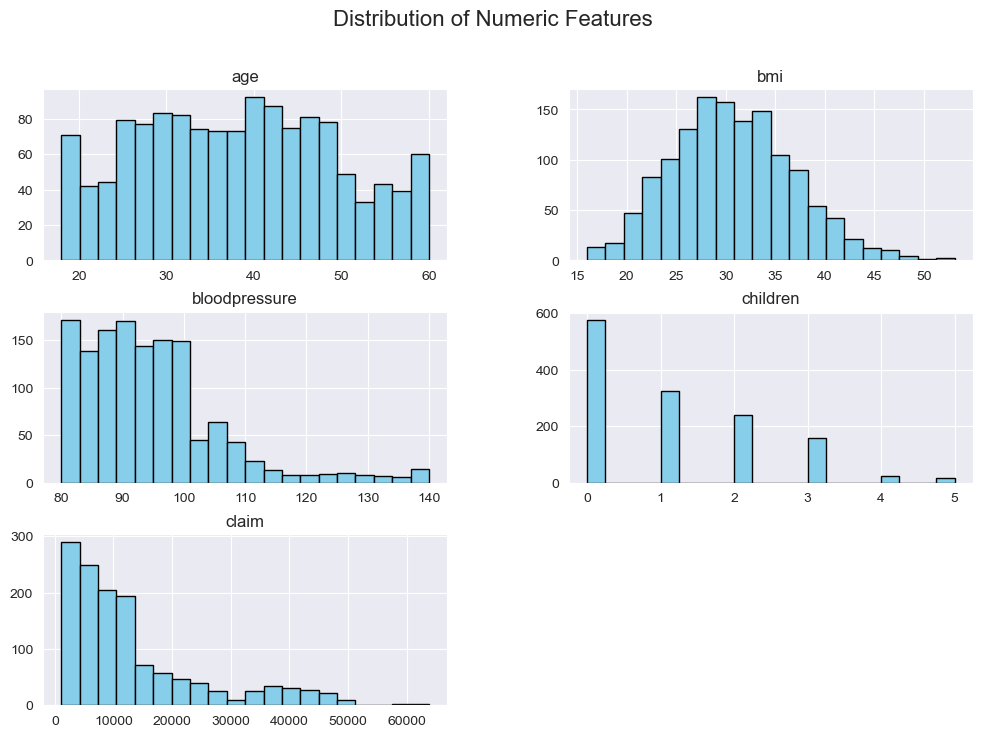

In [15]:
df[num_cols].hist(bins=20, figsize= (12,8), color= "skyblue", edgecolor = "black")
plt.suptitle("Distribution of Numeric Features", fontsize = 16)
plt.show()

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1332 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1332 non-null   int64  
 1   age            1332 non-null   float64
 2   gender         1332 non-null   object 
 3   bmi            1332 non-null   float64
 4   bloodpressure  1332 non-null   int64  
 5   diabetic       1332 non-null   object 
 6   children       1332 non-null   int64  
 7   smoker         1332 non-null   object 
 8   region         1332 non-null   object 
 9   claim          1332 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 114.5+ KB


In [29]:
cat_cols = ["gender","diabetic","smoker","region"]

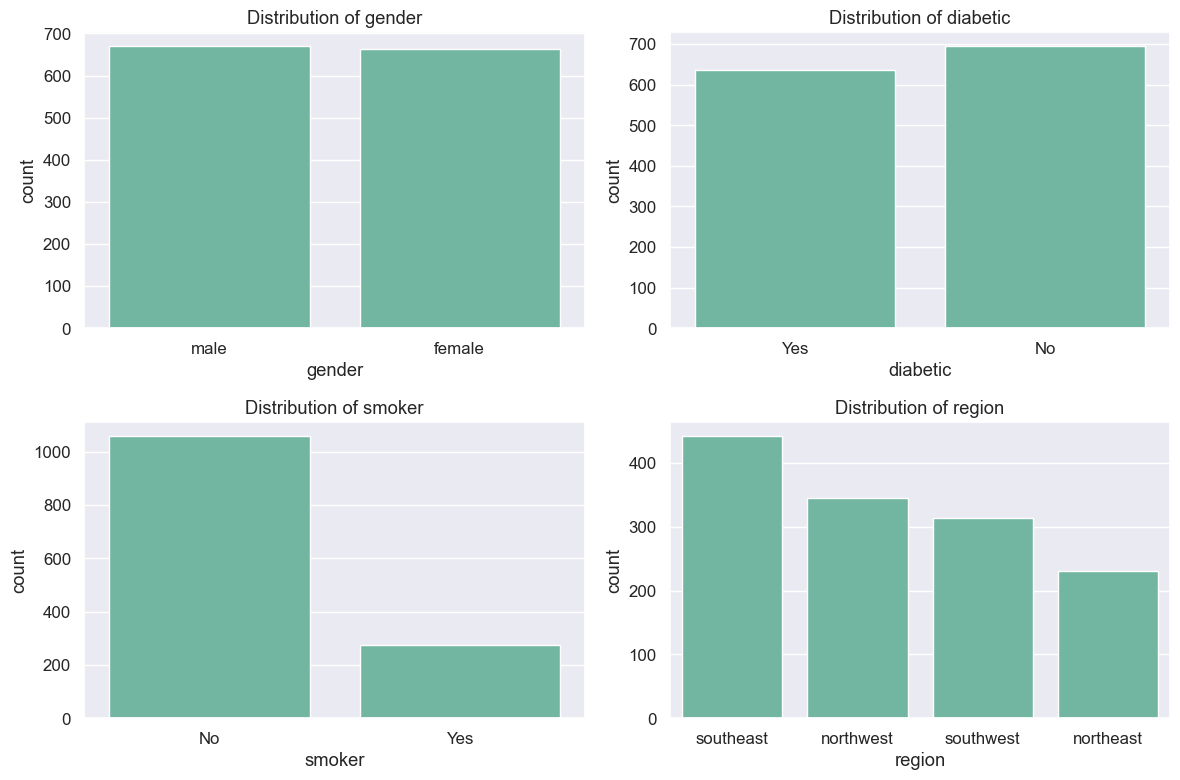

In [30]:
plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols,1):
    plt.subplot(2,2,i)
    sns.countplot(data = df, x = col)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Exploratory Data Analysis

In [31]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

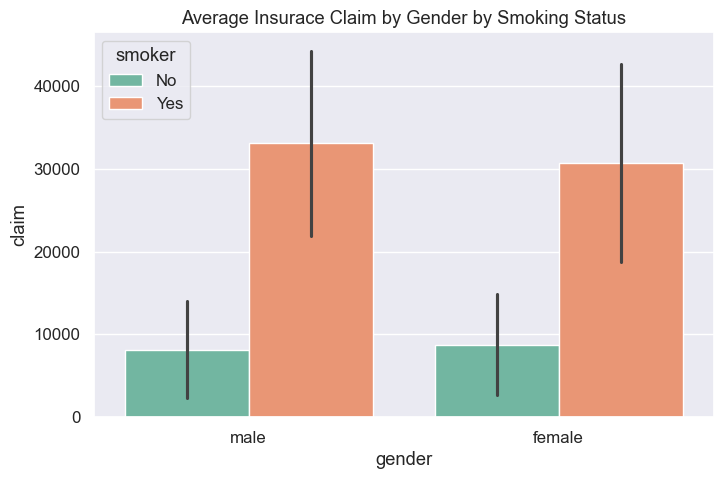

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(data= df, x= "gender", y = "claim", hue="smoker", estimator= "mean", errorbar="sd")
plt.title("Average Insurace Claim by Gender by Smoking Status")
plt.show()

In [33]:
pivot_region_diabetic = df.groupby(["region", "diabetic"])["claim"].mean().unstack()

In [34]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


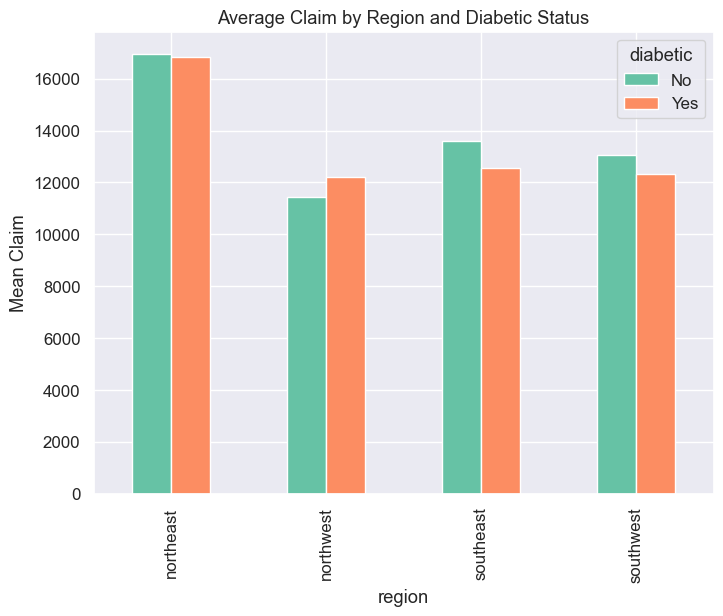

In [35]:
pivot_region_diabetic.plot(kind= "bar", figsize=(8,6))
plt.title("Average Claim by Region and Diabetic Status")
plt.ylabel("Mean Claim")
plt.show()

In [36]:
pivot_table = pd.pivot_table(df, values= "claim", index="region", columns= "smoker", aggfunc= "mean")

In [37]:
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [38]:
pivot_table = pd.pivot_table(df, values= "claim", index="children", columns= "smoker", aggfunc= "mean")

In [39]:
pivot_table

smoker,No,Yes
children,,
0,7698.05,31341.36
1,8303.11,31822.65
2,9493.09,33844.24
3,9614.52,32724.92
4,12121.34,26532.28
5,8183.85,19023.26


In [40]:
df[num_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


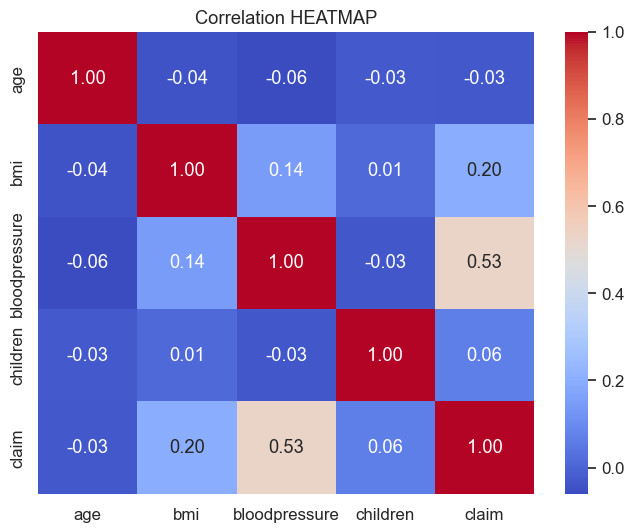

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt= ".2f")
plt.title("Correlation HEATMAP")
plt.show()

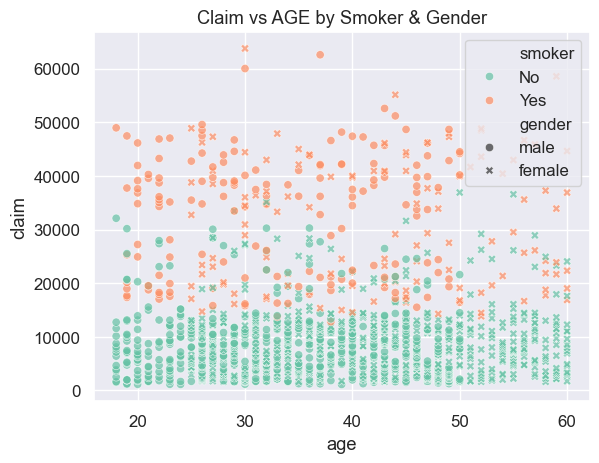

<Figure size 800x600 with 0 Axes>

In [42]:
sns.scatterplot(data = df, x= "age", y = "claim", hue="smoker", style="gender", alpha = 0.7)
plt.title("Claim vs AGE by Smoker & Gender")
plt.figure(figsize=(8,6))
plt.show()

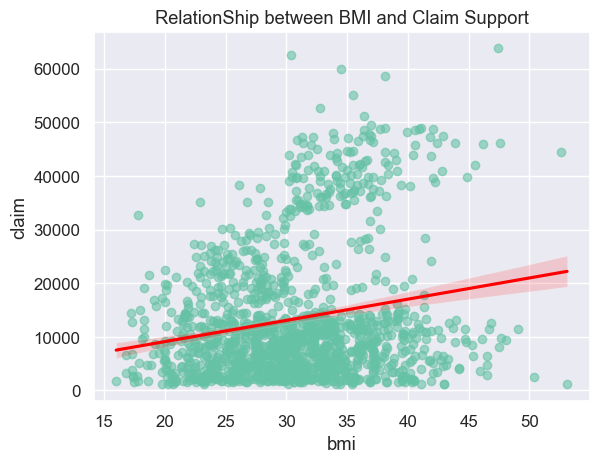

In [44]:
sns.regplot(data=df, x="bmi", y = "claim", scatter_kws= {"alpha":0.6}, line_kws={"color": "red"})
plt.title("RelationShip between BMI and Claim Support")
plt.show()

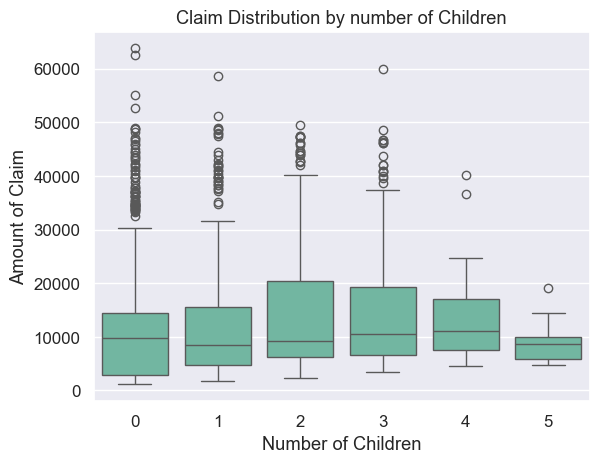

In [45]:
sns.boxplot(data= df, x = "children",y = "claim")
plt.title("Claim Distribution by number of Children")
plt.ylabel("Amount of Claim")
plt.xlabel("Number of Children")
plt.show()

In [46]:
df["age_group"] = pd.cut(df["age"], bins = [0,18,30,45,60,100], labels =["<18","18-30","31-45","46-60","60+"])

In [47]:
df.sample(3)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
473,474,48.00,female,33.00,99,No,0,No,northwest,6571.02,46-60
94,95,48.00,female,34.60,99,No,0,No,southwest,2020.18,46-60
1026,1027,36.00,male,25.70,96,Yes,4,Yes,southwest,17942.11,31-45


In [48]:
df["age_group"].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

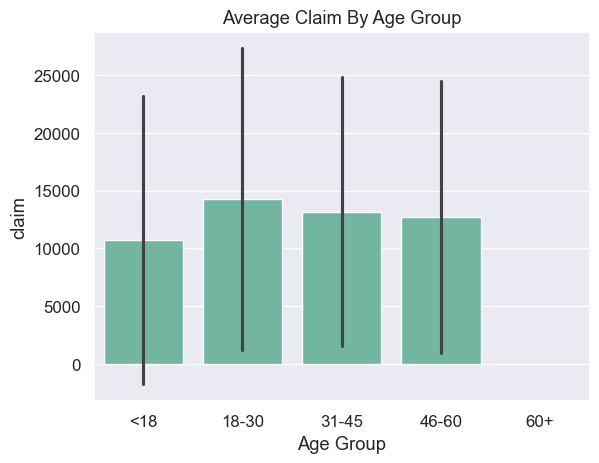

In [49]:
sns.barplot(data=df, x="age_group", y = "claim", estimator="mean", errorbar= "sd")
plt.title("Average Claim By Age Group")
plt.xlabel("Age Group")
plt.show()

In [50]:
df["bmi_category"] = pd.cut(df["bmi"], bins = [0,18.5,24.9,29.9,100], labels = ["Underweight","Normal","Overweight","Obese"]) 

In [51]:
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

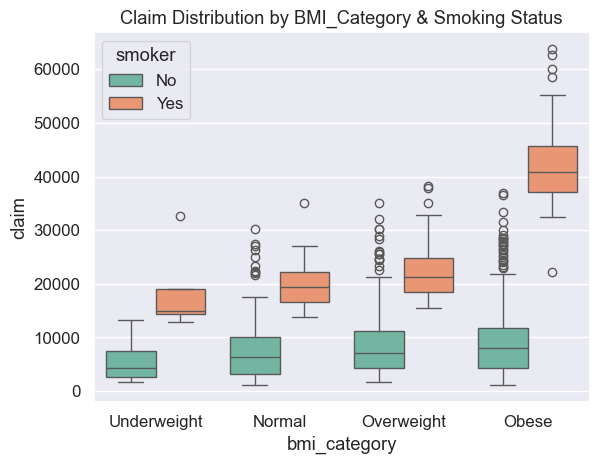

In [52]:
sns.boxplot(data = df, x = "bmi_category", y = "claim", hue = "smoker")
plt.title("Claim Distribution by BMI_Category & Smoking Status")
plt.show()

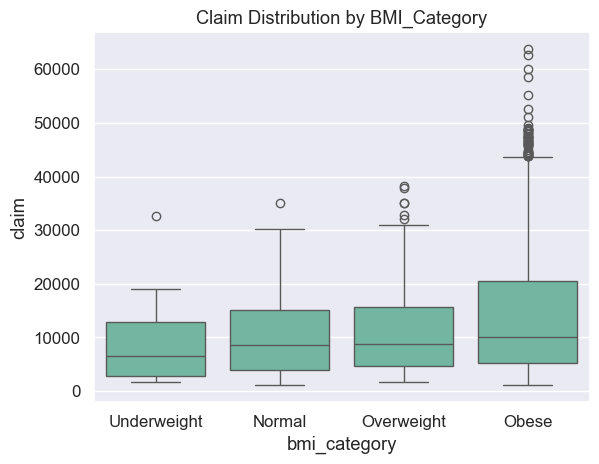

In [53]:
sns.boxplot(data = df, x = "bmi_category", y = "claim")
plt.title("Claim Distribution by BMI_Category")
plt.show()

In [54]:
import warnings
warnings.filterwarnings("ignore")

In [55]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x=="Yes").mean()*100),
    mean_claim = ("claim", "mean")
).reset_index()

In [56]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


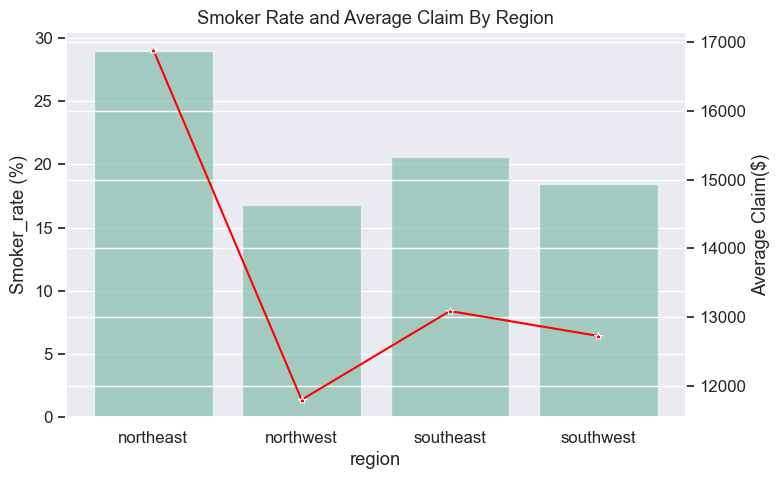

In [57]:
fig, ax1 = plt.subplots(figsize =(8,5))
sns.barplot(data = region_stats, x = "region", y= "smoker_rate", ax = ax1, alpha = 0.6)
ax2 = ax1.twinx()
sns.lineplot(data = region_stats, x= "region", y = "mean_claim", ax = ax2, color = "red", marker = "*")


ax1.set_ylabel("Smoker_rate (%)")
ax2.set_ylabel("Average Claim($)")
plt.title("Smoker Rate and Average Claim By Region")
plt.show()

In [58]:
df.sample(5)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group,bmi_category
60,61,49.00,male,35.20,80,Yes,1,No,southeast,1727.54,46-60,Obese
472,473,31.00,female,27.30,86,Yes,1,No,southeast,6555.07,31-45,Overweight
671,672,34.00,male,36.00,100,Yes,1,No,southeast,9386.16,31-45,Obese
854,855,50.00,male,25.50,87,No,0,No,northwest,12124.99,46-60,Overweight
1203,1204,26.00,male,34.80,94,Yes,0,Yes,southwest,34779.62,18-30,Obese


# Modeling

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [61]:
import joblib

In [62]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [63]:
X = df[["age", "gender", "bmi", "bloodpressure", "diabetic", "children", "smoker"]]
y = df["claim"]

In [65]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [66]:
cat_cols = ["gender", "diabetic", "smoker"]
label_encoders = {}

In [67]:
from sklearn.preprocessing import LabelEncoder
import joblib

cat_cols = ["gender", "diabetic", "smoker"]
label_encoders = {}  # this is the dictionary to store encoders

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # save encoder in dictionary

# save each encoder as a .pkl file
joblib.dump(label_encoders["gender"], "label_encoder_gender.pkl")
joblib.dump(label_encoders["diabetic"], "label_encoder_diabetic.pkl")
joblib.dump(label_encoders["smoker"], "label_encoder_smoker.pkl")

['label_encoder_smoker.pkl']

In [68]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [70]:
num_cols = ["age", "bmi", "bloodpressure","children"]
scaler = StandardScaler()

In [71]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [72]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [73]:
joblib.dump(label_encoders, "encoder.pkl")

['encoder.pkl']

In [74]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [75]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


In [76]:
from sklearn.linear_model import LinearRegression

In [77]:
from sklearn.preprocessing import PolynomialFeatures

In [78]:
from sklearn.ensemble import RandomForestRegressor

In [79]:
from sklearn.svm import SVR

In [80]:
from sklearn.model_selection import GridSearchCV, cross_val_score

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [82]:
from xgboost import XGBRegressor

In [83]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2" :  r2, "MAE": mae, "RMSE" : rmse}

In [84]:
results = {}

In [85]:
lr= LinearRegression()
lr.fit(X_train, y_train)
results["Linear Regression"] = evaluate_model(lr,X_train,X_test, y_train, y_test)
print("Linear Rregression model trained")


best_poly_model = None
best_poly_score = -np.inf

for degree in [2,3]:
    poly = PolynomialFeatures(degree= degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)

    score = poly_lr.score(X_test_poly, y_test)

    if score > best_poly_score:

        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)
        
degree, poly, poly_lr = best_poly_model

results[f"Polynomial Regression (deg = {degree})"] = evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test)
print("PolynomiAL Regression models are trained")



rf = RandomForestRegressor()
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split" : [2,5],
    "min_samples_leaf" : [1,2]
}

rf_grid = GridSearchCV(rf, rf_params, cv = 3, scoring= "r2", n_jobs = -1, verbose = 0)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)

print("Randome Forest training is Completed, best parameters:", rf_grid.best_params_)


svr = SVR()

svr_params ={
    "kernel" : ["rbf", "poly", "linear"],
    "C" : [1, 10,50],  
    "epsilon": [0.1, 0.2,0.5],
    "degree" : [2,3]
}

svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring = "r2", n_jobs = -1, verbose = 0)
svr_grid.fit(X_train, y_train)
best_svr = svr_grid.best_estimator_

results["SVR"] = evaluate_model(best_svr, X_train, X_test, y_train, y_test)
print("SVR Traing is Completed, best parameters :", svr_grid.best_params_)


xgb = XGBRegressor(objective = "reg:squarederror")

xgb_params = {
    "n_estimators": [100,200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.8,1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv = 3, scoring = "r2", n_jobs = -1, verbose = 0)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(best_xgb, X_train,X_test, y_train, y_test)
print("XGBoost trainingg is completed, best parameters:", xgb_grid.best_params_)


Linear Rregression model trained
PolynomiAL Regression models are trained
Randome Forest training is Completed, best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
SVR Traing is Completed, best parameters : {'C': 50, 'degree': 2, 'epsilon': 0.5, 'kernel': 'linear'}
XGBoost trainingg is completed, best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [86]:
results_df = pd.DataFrame(results).T
results_df.sort_values("R2", ascending=False)

,R2,MAE,RMSE
XGBoost,0.74,4247.90,5639.60
Random Forest,0.73,4420.68,5782.34
Polynomial Regression (deg = 2),0.67,4835.09,6372.02
Linear Regression,0.61,5329.59,6898.36
SVR,0.46,5883.87,8145.20


In [87]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "Random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [88]:
best_r2 = results_df["R2"].max()

In [89]:
best_r2

0.7388708497617429

In [90]:
top_model = results_df[results_df["R2"] == best_r2]

In [91]:
top_model

,R2,MAE,RMSE
XGBoost,0.74,4247.90,5639.60


In [92]:
best_model = models[top_model.index[0]]

In [93]:
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [94]:
joblib.dump(best_model, "best_model.pkl")
print(f"Best Model Selected: {top_model.index[0]}")

Best Model Selected: XGBoost


In [95]:
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']